<a href="https://colab.research.google.com/github/rmnmr13/SATAID_example/blob/main/Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/Colab_Satellite_Images"
os.makedirs(save_path, exist_ok=True)

!cp H08_EH_Indonesia.png /content/drive/MyDrive/Colab_Satellite_Images/

print("Image successfully saved to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot stat 'H08_EH_Indonesia.png': No such file or directory
Image successfully saved to Google Drive.


In [ ]:
# @title 1.2 Install Required Python Packages
# Install sataid package
!pip install sataid
!pip install --extra-index-url https://test.pypi.org/simple/ sataid==0.3.3
#install supoorting package
!pip install cartopy rasterio
import os
import glob
import sataid as sat
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

Looking in indexes: https://pypi.org/simple, https://test.pypi.org/simple/


In [ ]:
INPUT_DIR  = '/content/drive/MyDrive/Colab_data'
OUTPUT_DIR = "/content/drive/MyDrive/Colab_Satellite_Images"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
# FILTER WAKTU
# FORMAT : YYYYMMDDHHMM

START_TIME = "202605140000"
END_TIME   = "202605140100"

start_dt = datetime.strptime(START_TIME, "%Y%m%d%H%M")
end_dt   = datetime.strptime(END_TIME, "%Y%m%d%H%M")

#from datetime import timedelta
#now = datetime.utcnow()

#START_TIME = (now - timedelta(hours=3)).strftime("%Y%m%d%H%M")
#END_TIME   = now.strftime("%Y%m%d%H%M")

In [ ]:
# LIST FILE SATAID

files = sorted(glob.glob(os.path.join(INPUT_DIR, '*B13*.Z*')))

print("Total file ditemukan:", len(files))

Total file ditemukan: 7


In [ ]:
# FUNGSI AMBIL WAKTU DARI NAMA FILE

def get_datetime_from_filename(filepath):
    filename = os.path.basename(filepath)

    try:
        # Contoh:
        # H09_B13_Indonesia_20240908.Z0000

        date_str = filename.split('_')[-1].split('.Z')[0]
        time_str = filename.split('.Z')[-1][:4]

        dt = datetime.strptime(
            date_str + time_str,
            "%Y%m%d%H%M"
        )

        return dt

    except Exception as e:
        print("Gagal baca waktu:", filename)
        return None

In [ ]:
# FILTER FILE BERDASARKAN WAKTU

selected_files = []

for f in files:

    file_dt = get_datetime_from_filename(f)

    if file_dt is None:
        continue

    if start_dt <= file_dt <= end_dt:
        selected_files.append(f)

print("File sesuai rentang waktu:", len(selected_files))

File sesuai rentang waktu: 7


Processing: H09_B13_Indonesia_20260514.Z0000


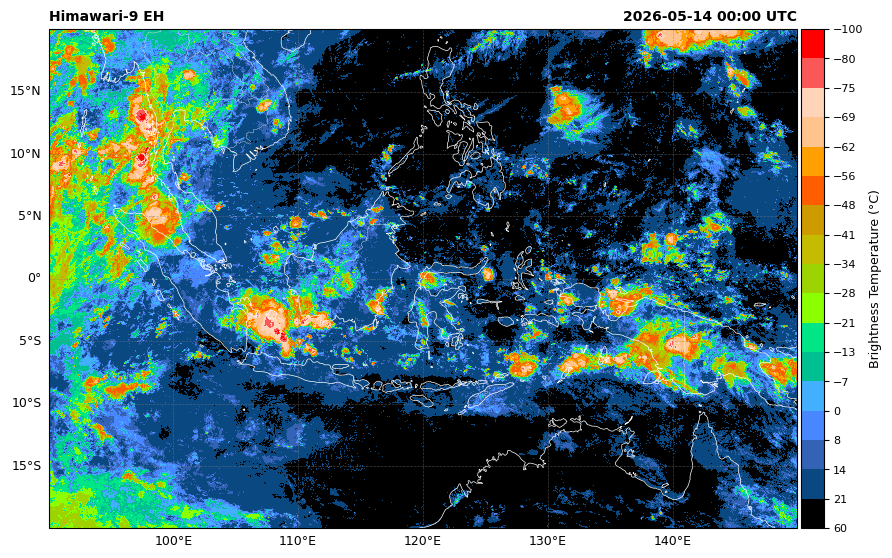

Saving plot to: /content/drive/MyDrive/Colab_Satellite_Images/H09_B13_Indonesia_20260514.Z0000.png
Saved: /content/drive/MyDrive/Colab_Satellite_Images/H09_B13_Indonesia_20260514.Z0000.png
Processing: H09_B13_Indonesia_20260514.Z0010


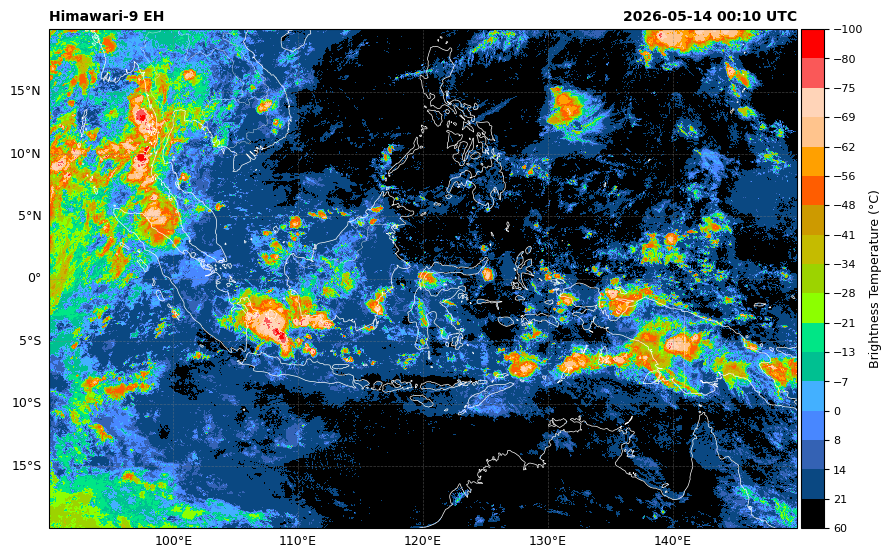

Saving plot to: /content/drive/MyDrive/Colab_Satellite_Images/H09_B13_Indonesia_20260514.Z0010.png
Saved: /content/drive/MyDrive/Colab_Satellite_Images/H09_B13_Indonesia_20260514.Z0010.png
Processing: H09_B13_Indonesia_20260514.Z0020


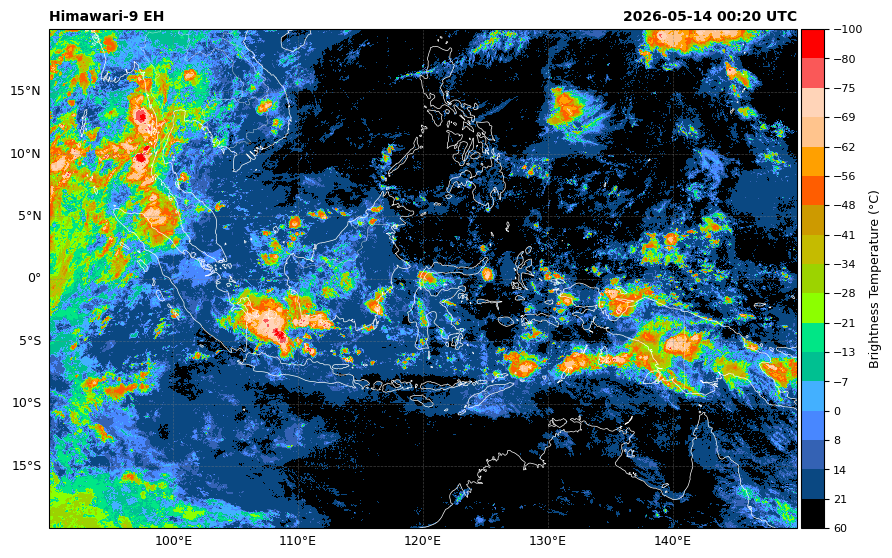

Saving plot to: /content/drive/MyDrive/Colab_Satellite_Images/H09_B13_Indonesia_20260514.Z0020.png
Saved: /content/drive/MyDrive/Colab_Satellite_Images/H09_B13_Indonesia_20260514.Z0020.png
Processing: H09_B13_Indonesia_20260514.Z0030


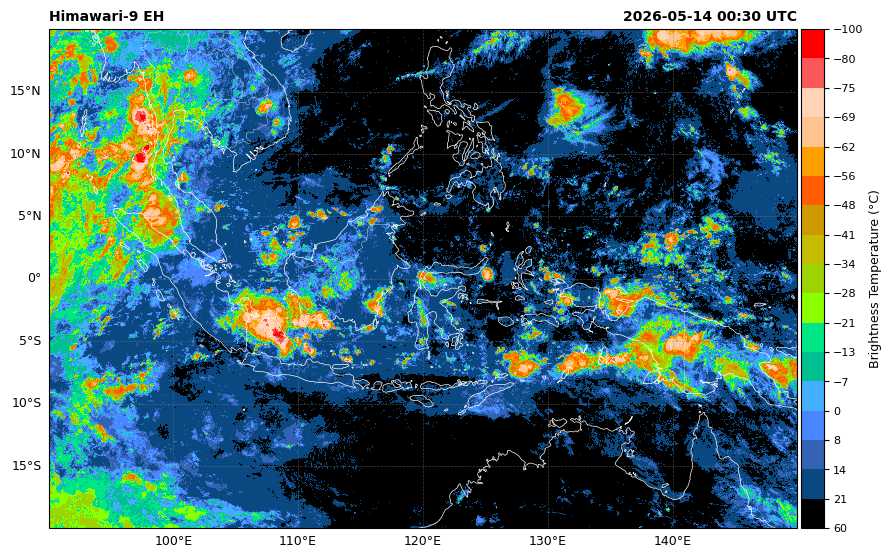

Saving plot to: /content/drive/MyDrive/Colab_Satellite_Images/H09_B13_Indonesia_20260514.Z0030.png
Saved: /content/drive/MyDrive/Colab_Satellite_Images/H09_B13_Indonesia_20260514.Z0030.png
Processing: H09_B13_Indonesia_20260514.Z0040


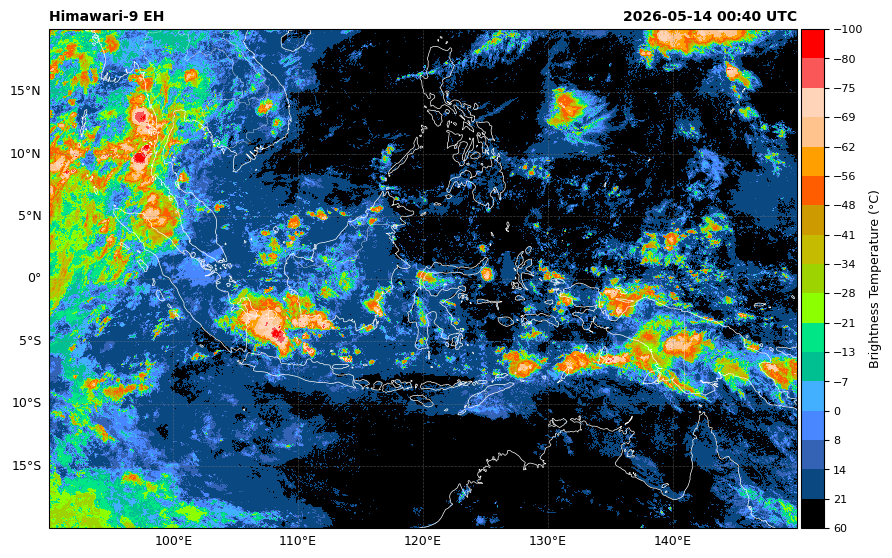

Saving plot to: /content/drive/MyDrive/Colab_Satellite_Images/H09_B13_Indonesia_20260514.Z0040.png
Saved: /content/drive/MyDrive/Colab_Satellite_Images/H09_B13_Indonesia_20260514.Z0040.png
Processing: H09_B13_Indonesia_20260514.Z0050


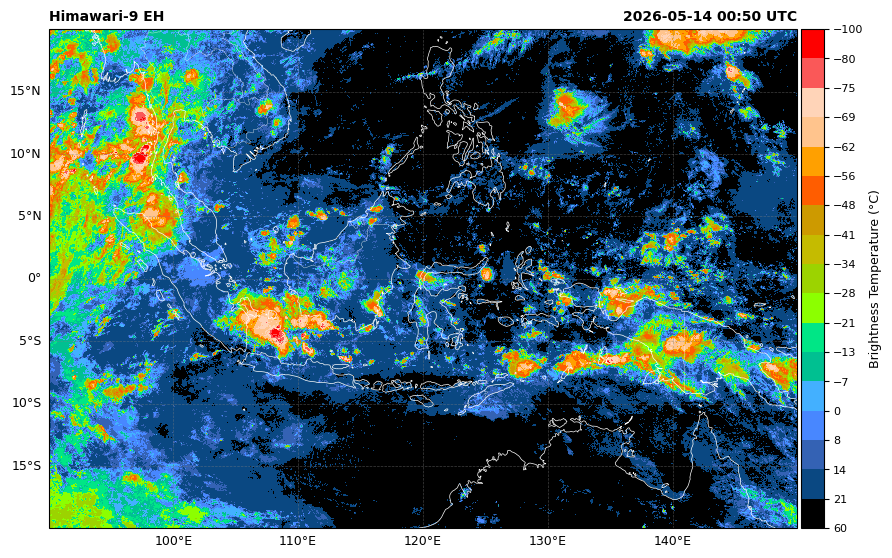

Saving plot to: /content/drive/MyDrive/Colab_Satellite_Images/H09_B13_Indonesia_20260514.Z0050.png
Saved: /content/drive/MyDrive/Colab_Satellite_Images/H09_B13_Indonesia_20260514.Z0050.png
Processing: H09_B13_Indonesia_20260514.Z0100


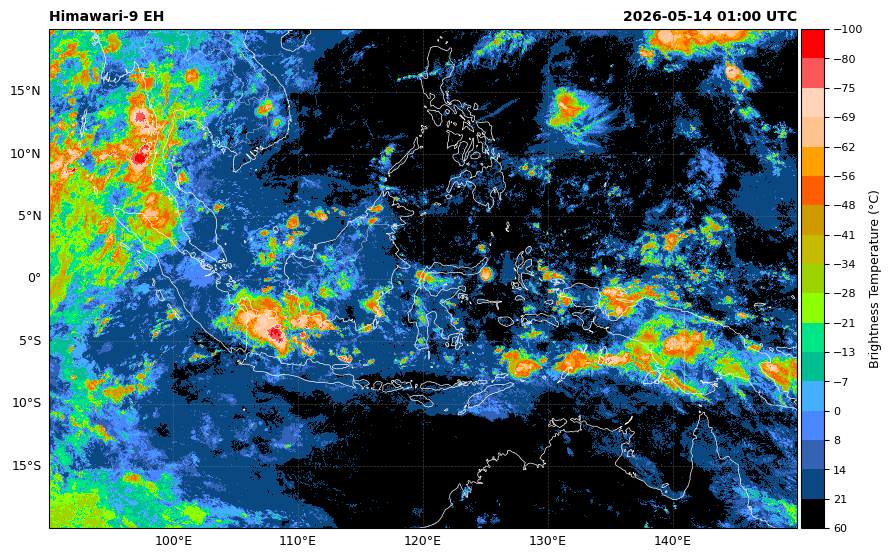

Saving plot to: /content/drive/MyDrive/Colab_Satellite_Images/H09_B13_Indonesia_20260514.Z0100.png
Saved: /content/drive/MyDrive/Colab_Satellite_Images/H09_B13_Indonesia_20260514.Z0100.png
DONE


In [ ]:
# FUNGSI PLOT

def create_image(sataid_file):

    try:
        filename = os.path.basename(sataid_file)
        print("Processing:", filename)

        # READ SATAID
        ds = sat.read_sataid(sataid_file)

        # PLOT LANGSUNG DARI SATAID ARRAY
        plt.close('all')

        a = ds.plot(cmap='EH')

        #fig = plt.gcf()
        #fig.set_size_inches(16, 8)

        plt.title(filename)

        # OUTPUT PNG
        output_png = os.path.join(
            OUTPUT_DIR,
            filename + '.png'
        )

        ds.savefig(output_png, cmap='EH')

        #plt.savefig(
       #     output_png,
       #     dpi=150,
       #     bbox_inches='tight'
       # )

        #plt.savefig(
       #     output_png
       #     dpi=150,
       #     bbox_inches='tight'
       # )

        plt.close('all')

        print("Saved:", output_png)

    except Exception as e:
        print("ERROR:", sataid_file)
        print(e)
# LOOP FILE
for f in selected_files:
    create_image(f)

print("DONE")


In [ ]:
# =========================================================
# INSTALL PACKAGE
# =========================================================
!pip install --extra-index-url https://test.pypi.org/simple/ sataid==0.3.3
!pip install cartopy rasterio

# =========================================================
# IMPORT LIBRARY
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import sataid as sat
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# =========================================================
# DIREKTORI INPUT DAN OUTPUT
# =========================================================
INPUT_DIR  = "/content/drive/MyDrive/Colab_data"
OUTPUT_DIR = "/content/drive/MyDrive/Colab_Satellite_Images"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================================================
# FILTER WAKTU
# FORMAT: YYYYMMDDHHMM
# =========================================================
START_TIME = "202605140000"
END_TIME   = "202605140100"

start_dt = datetime.strptime(START_TIME, "%Y%m%d%H%M")
end_dt   = datetime.strptime(END_TIME, "%Y%m%d%H%M")

# =========================================================
# LIST FILE SATAID
# =========================================================
files = sorted(
    glob.glob(
        os.path.join(INPUT_DIR, "*B13*.Z*")
    )
)

print("Total file ditemukan:", len(files))

# =========================================================
# FUNGSI AMBIL WAKTU DARI NAMA FILE
# =========================================================
def get_datetime_from_filename(filepath):

    filename = os.path.basename(filepath)

    try:
        # Contoh:
        # H09_B13_Indonesia_20260514.Z0010

        date_str = filename.split("_")[-1].split(".Z")[0]
        time_str = filename.split(".Z")[-1][:4]

        dt = datetime.strptime(
            date_str + time_str,
            "%Y%m%d%H%M"
        )

        return dt

    except Exception as e:
        print("Gagal baca waktu:", filename, e)
        return None

# =========================================================
# FILTER FILE BERDASARKAN WAKTU
# =========================================================
selected_files = []

for f in files:

    file_dt = get_datetime_from_filename(f)

    if file_dt is None:
        continue

    if start_dt <= file_dt <= end_dt:
        selected_files.append(f)

print("File sesuai rentang waktu:", len(selected_files))

if len(selected_files) == 0:
    print("Tidak ada file dalam rentang waktu yang dipilih.")

# =========================================================
# FUNGSI PLOT DAN SIMPAN CITRA
# =========================================================
def create_image(sataid_file):

    try:
        filename = os.path.basename(sataid_file)

        print("Processing:", filename)

        ds = sat.read_sataid(sataid_file)

        output_png = os.path.join(
            OUTPUT_DIR,
            filename + ".png"
        )

        ds.savefig(
            output_png,
            cmap="EH"
        )

        plt.close("all")

        print("Saved:", output_png)

    except Exception as e:
        print("ERROR:", sataid_file)
        print(e)

# =========================================================
# LOOP FILE
# =========================================================
for f in selected_files:
    create_image(f)

print("DONE")